# 특이케이스 분석 (Case A~E)

### 1-1. 특이 케이스 A~E — 케이스 정의

**케이스 정의 (이 섹션에서부터 반복적으로 등장하는 Case A/B)**
- **Case A** = 발라드 + 가사 복잡도 중앙값 미만(단순) + 조회수 중앙값 미만(저조회) — 가사도 단순하고 흥행도 못 한 그룹
- **Case B** = 댄스 + 영어 비중 높음 + 가사 복잡도 높음(밀도 높은/랩 비중 높은 텍스트) + 조회수 높음 — 가사가 헤비한데 흥행한 그룹

이후 등장하는 Case C~E는 이 복잡도×조회수 축을 다르게 조합해 추가로 정의됩니다.

In [ ]:
import pandas as pd
import numpy as np

# 1. 가사 복잡도 지수(Complexity Index) 생성
# 고유 단어 비중과 전체 토큰 수를 0~1 사이로 정규화하여 합산 평균을 냅니다.
df_final['lyrics_complexity_index'] = (
    (df_final['unique_token_ratio'] - df_final['unique_token_ratio'].min()) / (df_final['unique_token_ratio'].max() - df_final['unique_token_ratio'].min()) +
    (df_final['token_count'] - df_final['token_count'].min()) / (df_final['token_count'].max() - df_final['token_count'].min())
) / 2

# 2. 분석 실행 (Case A: 단순한 발라드 / Case B: 복잡한 댄스 메가히트)
ballad_case, dance_case = analyze_exception_cases(df_final)

# 3. [추가 요청 사항] 상위 10% 댄스곡 중 복잡도 순으로 정렬
top_10_threshold = df_final['api_view_count'].quantile(0.9)
top_dance_complex = df_final[
    (df_final['api_view_count'] >= top_10_threshold) &
    (df_final['genie_genre'].str.contains('댄스', na=False))
].sort_values(by='lyrics_complexity_index', ascending=False)

print(f"✅ 가사 복잡도 지수(Index) 기준 상위 10% 댄스곡 목록")
display(top_dance_complex[['songName', 'artists', 'lyrics_complexity_index', 'api_view_count', 'english_ratio']].head(10))

✅ 가사 복잡도 지수(Index) 기준 상위 10% 댄스곡 목록


,songName,artists,lyrics_complexity_index,api_view_count,english_ratio
137,MANIAC,2230|VIVIZ|VIVIZ|1,0.334859,61413951,0.4188
91,BADVILLAIN,2983|BADVILLAIN (배드빌런)|BADVILLAIN|1,0.334372,51438283,0.5915
192,뭣 같아,2595|BOYNEXTDOOR|BOYNEXTDOOR|1,0.330588,43878606,0.1602
135,Baggy Jeans,1329|NCT U|NCTU|1,0.308383,71076279,0.5385
145,ISTJ,1078|NCT DREAM|NCTDREAM|1,0.305675,69264659,0.3097
155,WATCH IT,371|더보이즈(THE BOYZ)|THEBOYZ|1,0.301791,49956730,0.4731
138,Off The Record,2244|IVE (아이브)|IVE|1,0.298041,64086889,0.3684
31,Drama,2023|aespa|aespa|1,0.295589,283557314,0.4868
182,Talk Saxy,2688|RIIZE (라이즈)|RIIZE|1,0.292098,43658974,0.5282
12,Ice On My Teeth,393|ATEEZ (에이티즈)|ATEEZ|1,0.291702,95858203,0.5073


In [ ]:
import pandas as pd

def analyze_exception_cases(df):
    # 1. 장르명 전처리 (공백 제거 및 결측치 처리)
    df['genie_genre'] = df['genie_genre'].astype(str).str.strip()

    # 2. 기준점 설정 (전체 데이터의 중앙값)
    median_complexity = df['lyrics_complexity_index'].median()
    median_views = df['api_view_count'].median()

    # [Case A] 발라드 특이 케이스: 단순한 가사 & 저조회수
    # 특징: 가사 정보량이 적고 반복적이지만, 대중의 선택(조회수)도 받지 못한 그룹
    ballad_simple_low = df[
        (df['genie_genre'].str.contains('발라드', na=False)) &
        (df['lyrics_complexity_index'] < median_complexity) &
        (df['api_view_count'] < median_views)
    ].copy()

    # [Case B] 댄스 특이 케이스: 복잡한 가사 & 고조회수
    # 특징: 영어 비중이 높고 가사 밀도가 높은 '텍스트 헤비'형 성공곡
    # (주의: 이 그룹에는 가사가 단순한 'Mantra' 같은 곡은 빠지게 됩니다.
    # 대신 랩 파트가 많거나 가사 전달량이 많은 곡들이 추출됩니다.)
    dance_complex_high = df[
        (df['genie_genre'].str.contains('댄스', na=False)) &
        (df['english_ratio'] >= 0.7) &  # 영어 비중 70% 이상 (사용자 가설 유지)
        (df['lyrics_complexity_index'] > median_complexity) &
        (df['api_view_count'] > median_views)
    ].copy()

    return ballad_simple_low, dance_complex_high

# --- 실행 및 결과 출력 ---
ballad_case, dance_case = analyze_exception_cases(df_final)

print(f"📊 [Case A] 발라드 (단순/저조회) 추출 수: {len(ballad_case)}")
if not ballad_case.empty:
    display(ballad_case[['songName', 'artists', 'lyrics_complexity_index', 'api_view_count', 'repeated_token_ratio']].head())

print(f"\n🚀 [Case B] 댄스 (복잡/고조회) 추출 수: {len(dance_case)}")
if not dance_case.empty:
    # speechiness 컬럼이 데이터에 없는 경우를 대비해 처리
    cols = ['songName', 'artists', 'english_ratio', 'api_view_count', 'lyrics_complexity_index', 'token_count']
    if 'speechiness' in dance_case.columns:
        cols.append('speechiness')
    display(dance_case[cols].head())
else:
    print("조건에 맞는 댄스곡이 없습니다. 영어 비중(0.7)이나 복잡도 기준을 조금 낮춰보세요.")

📊 [Case A] 발라드 (단순/저조회) 추출 수: 44


,songName,artists,lyrics_complexity_index,api_view_count,repeated_token_ratio
214,그대만의 노래,1595|임한별||0,0.253822,1545243,0.5733
251,Hypnotized,1501|헨리 (HENRY)|HENRY|1,0.192293,966003,0.6766
294,잡초 (With 장혜진),1029|후이|HUI|1,0.255489,3571755,0.5307
426,루퍼트의 눈물 (Rupert's drop),600|원어스 (ONEUS)|ONEUS|1,0.194871,434355,0.6420
548,PINK CHRISTMAS,306|Apink (에이핑크)|Apink|1,0.219151,3425062,0.6744



🚀 [Case B] 댄스 (복잡/고조회) 추출 수: 5


,songName,artists,english_ratio,api_view_count,lyrics_complexity_index,token_count,speechiness
2,Strategy (feat. Megan Thee Stallion),5|TWICE (트와이스)|TWICE|1,0.8039,137777976,0.283676,724,0.155489
8,Mantra,682|제니 (JENNIE)|JENNIE|1,0.7883,229896119,0.264158,529,0.257387
37,3D (feat. Jack Harlow),410|정국|JUNGKOOK|1,0.7797,270450262,0.284783,690,0.181120
228,SLAY,680|EVERGLOW (에버글로우)|EVERGLOW|1,0.7136,32723811,0.264996,604,0.534689
283,Tell My Momma,1582|카드 (KARD)|KARD|1,0.7377,6404414,0.322729,770,0.617166


### 1-2. Case B 에너지 수치 확인

**분석**: Case B(고복잡도 댄스 성공곡)의 평균 에너지를 전체 평균 에너지와 비교.
**결과**: Case B는 에너지가 압도적으로 높지 않음 → '강한 비트'보다 '가사의 밀도·메시지'로 성공했다는 해석 ("에너지가 낮아도 가사가 힙하고 빽빽하면 댄스곡으로 성공할 수 있다").

In [ ]:
# 전체 평균 에너지 vs Case B 평균 에너지 비교
total_energy_mean = df_final['energy'].mean()
case_b_energy_mean = dance_case['energy'].mean()

print(f"📊 [에너지 수치 비교]")
print(f"- 전체 곡 평균 에너지: {total_energy_mean:.4f}")
print(f"- Case B(성공 댄스) 평균 에너지: {case_b_energy_mean:.4f}")
print(f"- 차이: {((case_b_energy_mean - total_energy_mean) / total_energy_mean * 100):.1f}% 높음")

📊 [에너지 수치 비교]
- 전체 곡 평균 에너지: 0.2593
- Case B(성공 댄스) 평균 에너지: 0.2922
- 차이: 12.7% 높음


### 1-3. Case B 조회수 확인

**분석**: Case B 그룹 곡들의 전체 조회수 순위(`view_rank`)를 확인.

In [ ]:
# 1. 전체 데이터에서 순위 매기기
df_final['view_rank'] = df_final['api_view_count'].rank(ascending=False, method='min').astype(int)

# 2. Case B를 다시 추출 (view_rank 포함)
# 아까 만든 analyze_exception_cases 함수를 다시 쓰거나, 직접 필터링합니다.
median_complexity = df_final['lyrics_complexity_index'].median()
median_views = df_final['api_view_count'].median()

dance_case = df_final[
    (df_final['genie_genre'].str.contains('댄스', na=False)) &
    (df_final['english_ratio'] >= 0.7) &
    (df_final['lyrics_complexity_index'] > median_complexity) &
    (df_final['api_view_count'] > median_views)
].copy()

print("🚀 [Case B: 가사가 복잡한데 성공한 댄스곡 순위]")
display(dance_case[['view_rank', 'songName', 'artists', 'api_view_count', 'lyrics_complexity_index']].sort_values('view_rank'))

🚀 [Case B: 가사가 복잡한데 성공한 댄스곡 순위]


,view_rank,songName,artists,api_view_count,lyrics_complexity_index
37,12,3D (feat. Jack Harlow),410|정국|JUNGKOOK|1,270450262,0.284783
8,14,Mantra,682|제니 (JENNIE)|JENNIE|1,229896119,0.264158
2,25,Strategy (feat. Megan Thee Stallion),5|TWICE (트와이스)|TWICE|1,137777976,0.283676
228,130,SLAY,680|EVERGLOW (에버글로우)|EVERGLOW|1,32723811,0.264996
283,379,Tell My Momma,1582|카드 (KARD)|KARD|1,6404414,0.322729


### 1-4. Case C 정의 (단순 가사 + 초고조회)

**케이스 정의**: Case C = 조회수 상위 10% + 가사 복잡도 중앙값 미만 — 가사는 단순한데 초고조회를 기록한 그룹.
**분석**: Case B(복잡+히트)와 Case C(단순+히트)를 산점도로 비교.

In [ ]:
# [Case C] 가사는 단순(복잡도 낮음)한데, 조회수는 폭발(상위 10%)한 곡
top_10_views = df_final['api_view_count'].quantile(0.9)
median_complexity = df_final['lyrics_complexity_index'].median()

case_c_simple_hit = df_final[
    (df_final['api_view_count'] >= top_10_views) &
    (df_final['lyrics_complexity_index'] < median_complexity)
].copy()

print(f"🔥 [Case C] 단순함의 미학 (단순 가사/초고조회) 추출 수: {len(case_c_simple_hit)}")
display(case_c_simple_hit[['songName', 'artists', 'lyrics_complexity_index', 'api_view_count']].sort_values('api_view_count', ascending=False).head(10))

🔥 [Case C] 단순함의 미학 (단순 가사/초고조회) 추출 수: 56


,songName,artists,lyrics_complexity_index,api_view_count
0,APT. (ROSÉ & Bruno Mars),684|로제 (ROSÉ)|ROSE|1,0.177016,2309341434
20,Seven (feat. Latto) - Clean Ver.,410|정국|JUNGKOOK|1,0.245969,584810430
13,Rockstar,681|리사 (LISA)|LISA|1,0.205502,369355918
1,DRIP,2543|BABYMONSTER (베이비몬스터)|BABYMONSTER|1,0.254220,342120075
22,Magnetic,2853|아일릿(ILLIT)|ILLIT|1,0.236669,287144471
44,Super Shy,2463|NewJeans|NewJeans|1,0.172407,271996508
6,Whiplash,2023|aespa|aespa|1,0.243784,262211980
43,Standing Next to You,410|정국|JUNGKOOK|1,0.174688,214922974
16,CRAZY,2380|LE SSERAFIM (르세라핌)|LESSERAFIM|1,0.198629,195858257
73,Bite Me,2016|엔하이픈 (ENHYPEN)|ENHYPEN|1,0.205540,185748847


In [ ]:
# 1. 원본 데이터에서 전체 백분위 계산
df_final['view_percentile'] = df_final['api_view_count'].rank(pct=True)

# 2. Case B와 Case C를 다시 정의 (새로운 컬럼이 포함되도록)
# (기존에 정의한 필터링 조건을 그대로 사용하여 다시 'copy' 해옵니다)
top_10_views_threshold = df_final['api_view_count'].quantile(0.9)
median_complexity = df_final['lyrics_complexity_index'].median()
median_views = df_final['api_view_count'].median()

case_c_simple_hit = df_final[
    (df_final['api_view_count'] >= top_10_views_threshold) &
    (df_final['lyrics_complexity_index'] < median_complexity)
].copy()

dance_case_b = df_final[
    (df_final['genie_genre'].str.contains('댄스', na=False)) &
    (df_final['english_ratio'] >= 0.7) &
    (df_final['lyrics_complexity_index'] > median_complexity) &
    (df_final['api_view_count'] > median_views)
].copy()

print("🚀 [성공의 등급 비교]")
print(f"Case C (단순 대박) 평균 상위: {(1 - case_c_simple_hit['view_percentile'].mean())*100:.2f}%")
print(f"Case B (복잡한 성공) 평균 상위: {(1 - dance_case_b['view_percentile'].mean())*100:.2f}%")

🚀 [성공의 등급 비교]
Case C (단순 대박) 평균 상위: 4.97%
Case B (복잡한 성공) 평균 상위: 11.66%


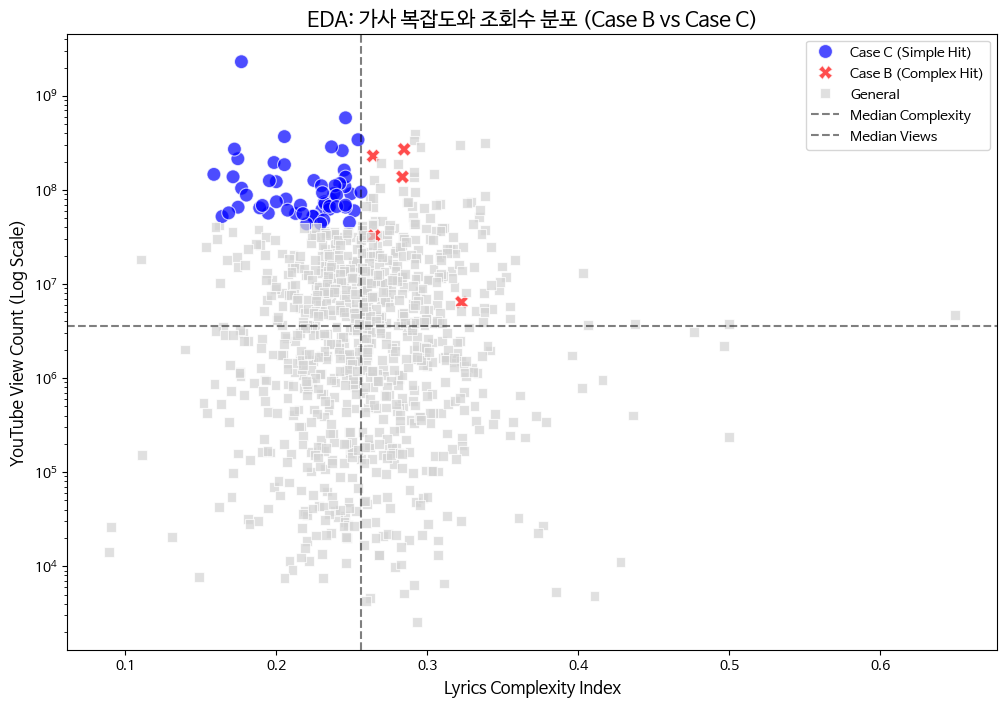

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 시각화를 위한 그룹 레이블링
df_final['group'] = 'General'
df_final.loc[case_c_simple_hit.index, 'group'] = 'Case C (Simple Hit)'
df_final.loc[dance_case_b.index, 'group'] = 'Case B (Complex Hit)'

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_final,
    x='lyrics_complexity_index',
    y='api_view_count',
    hue='group',
    style='group',
    palette={'General': 'lightgrey', 'Case C (Simple Hit)': 'blue', 'Case B (Complex Hit)': 'red'},
    alpha=0.7, s=100
)

# 기준선 표시 (중앙값)
plt.axvline(median_complexity, color='black', linestyle='--', alpha=0.5, label='Median Complexity')
plt.axhline(median_views, color='black', linestyle='--', alpha=0.5, label='Median Views')

plt.yscale('log') # 조회수 편차가 크므로 로그 스케일 적용
plt.title('EDA: 가사 복잡도와 조회수 분포 (Case B vs Case C)', fontsize=15)
plt.xlabel('Lyrics Complexity Index', fontsize=12)
plt.ylabel('YouTube View Count (Log Scale)', fontsize=12)
plt.legend()
plt.show()

### 1-5. Case B 확장 (모수 늘리기)

**분석**: Case B 기준을 완화(영어 비중 70%→50%, 복잡도 하위 40% 초과)해 표본을 늘린 버전.
**결과**: 일반 댄스곡 대비 평균 단어수 26%↑(539 tokens), 영어 비중 50%+ 유지, 반복도는 낮게 유지(고밀도이면서도 후렴 반복 유지) → '글로벌 퍼포먼스 그룹'들이 공통적으로 쓰는 [고밀도 가사 설계] 공식으로 판단.

⚠️ 이 제목의 'Case D'는 아래 idx114 부근에서 다시 정의되는 'Case D'와는 다른 의미입니다(여기서는 '기준 완화판 Case B'를 가리킴).

In [ ]:
# 기준 완화 버전 Case B 추출
median_views = df_final['api_view_count'].median()
complexity_threshold_low = df_final['lyrics_complexity_index'].quantile(0.4) # 하위 40% 이상으로 완화

dance_case_expanded = df_final[
    (df_final['genie_genre'].str.contains('댄스', na=False)) &
    (df_final['english_ratio'] >= 0.5) & # 영어 비중 70% -> 50% 완화
    (df_final['lyrics_complexity_index'] > complexity_threshold_low) &
    (df_final['api_view_count'] > median_views)
].copy()

print(f"✅ 확장된 Case B (복잡한 댄스 성공군) 추출 수: {len(dance_case_expanded)}곡")
display(dance_case_expanded[['view_rank', 'songName', 'artists', 'english_ratio', 'lyrics_complexity_index']].sort_values('view_rank').head(15))

✅ 확장된 Case B (복잡한 댄스 성공군) 추출 수: 48곡


,view_rank,songName,artists,english_ratio,lyrics_complexity_index
20,2,Seven (feat. Latto) - Clean Ver.,410|정국|JUNGKOOK|1,0.8302,0.245969
1,5,DRIP,2543|BABYMONSTER (베이비몬스터)|BABYMONSTER|1,0.5860,0.254220
37,12,3D (feat. Jack Harlow),410|정국|JUNGKOOK|1,0.7797,0.284783
8,14,Mantra,682|제니 (JENNIE)|JENNIE|1,0.7883,0.264158
2,25,Strategy (feat. Megan Thee Stallion),5|TWICE (트와이스)|TWICE|1,0.8039,0.283676
12,39,Ice On My Teeth,393|ATEEZ (에이티즈)|ATEEZ|1,0.5073,0.291702
117,55,Fact Check (불가사의; 不可思議),1328|NCT 127|NCT127|1,0.5592,0.286558
135,58,Baggy Jeans,1329|NCT U|NCTU|1,0.5385,0.308383
150,63,Party O'Clock,2298|NMIXX|NMIXX|1,0.5337,0.259657
72,65,KING KONG,1744|TREASURE (트레저)|TREASURE|1,0.5352,0.290033


📊 [상관계수 비교 결과]
 - 댄스 장르 (복잡도 vs 조회수): -0.0790
 - 발라드 장르 (복잡도 vs 조회수): -0.1564
--------------------------------------------------


<Figure size 1200x800 with 0 Axes>

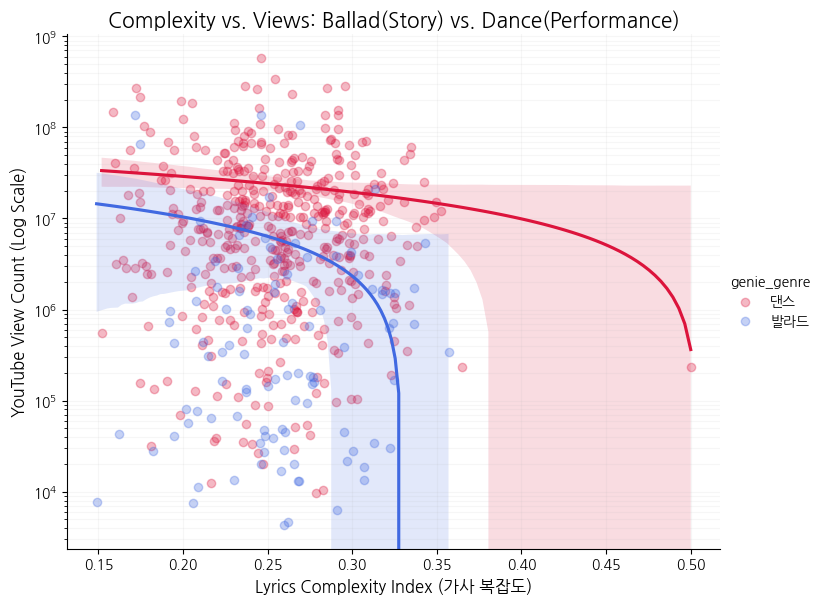

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 분석 대상 장르 필터링 (발라드 vs 댄스)
df_comparison = df_final[df_final['genie_genre'].str.contains('발라드|댄스', na=False)].copy()

# 2. 장르별 상관계수 계산 (복잡도 vs 조회수)
corr_dance = df_comparison[df_comparison['genie_genre'].str.contains('댄스')][['lyrics_complexity_index', 'api_view_count']].corr().iloc[0, 1]
corr_ballad = df_comparison[df_comparison['genie_genre'].str.contains('발라드')][['lyrics_complexity_index', 'api_view_count']].corr().iloc[0, 1]

print(f"📊 [상관계수 비교 결과]")
print(f" - 댄스 장르 (복잡도 vs 조회수): {corr_dance:.4f}")
print(f" - 발라드 장르 (복잡도 vs 조회수): {corr_ballad:.4f}")
print("-" * 50)

# 3. 시각화 (회귀선 비교)
plt.figure(figsize=(12, 8))
sns.lmplot(
    data=df_comparison,
    x='lyrics_complexity_index',
    y='api_view_count',
    hue='genie_genre',
    palette={'발라드': 'royalblue', '댄스': 'crimson'},
    scatter_kws={'alpha': 0.3},
    height=6, aspect=1.2
)

plt.yscale('log')
plt.title('Complexity vs. Views: Ballad(Story) vs. Dance(Performance)', fontsize=15)
plt.xlabel('Lyrics Complexity Index (가사 복잡도)', fontsize=12)
plt.ylabel('YouTube View Count (Log Scale)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.show()

In [ ]:
# Case B (고복잡도 댄스 성공군) vs 일반 댄스곡 비교
dance_all = df_final[df_final['genie_genre'].str.contains('댄스', na=False)].copy()
dance_all['is_case_b'] = dance_all.index.isin(dance_case_expanded.index)

case_b_analysis = dance_all.groupby('is_case_b')[['token_count', 'unique_token_ratio', 'lyrics_complexity_index']].mean()

print("📊 [Case B vs 일반 댄스곡 물리적 구조 비교]")
display(case_b_analysis)

📊 [Case B vs 일반 댄스곡 물리적 구조 비교]


,token_count,unique_token_ratio,lyrics_complexity_index
is_case_b,,,
False,427.529976,0.364867,0.253125
True,539.916667,0.347094,0.275776


### 1-6. Case B 확장 — 위치 EDA

**분석**: 위에서 확장한 Case B(제목상 'Case D')를 산점도(복잡도×조회수) 상에서 Case C와 함께 시각적으로 비교.

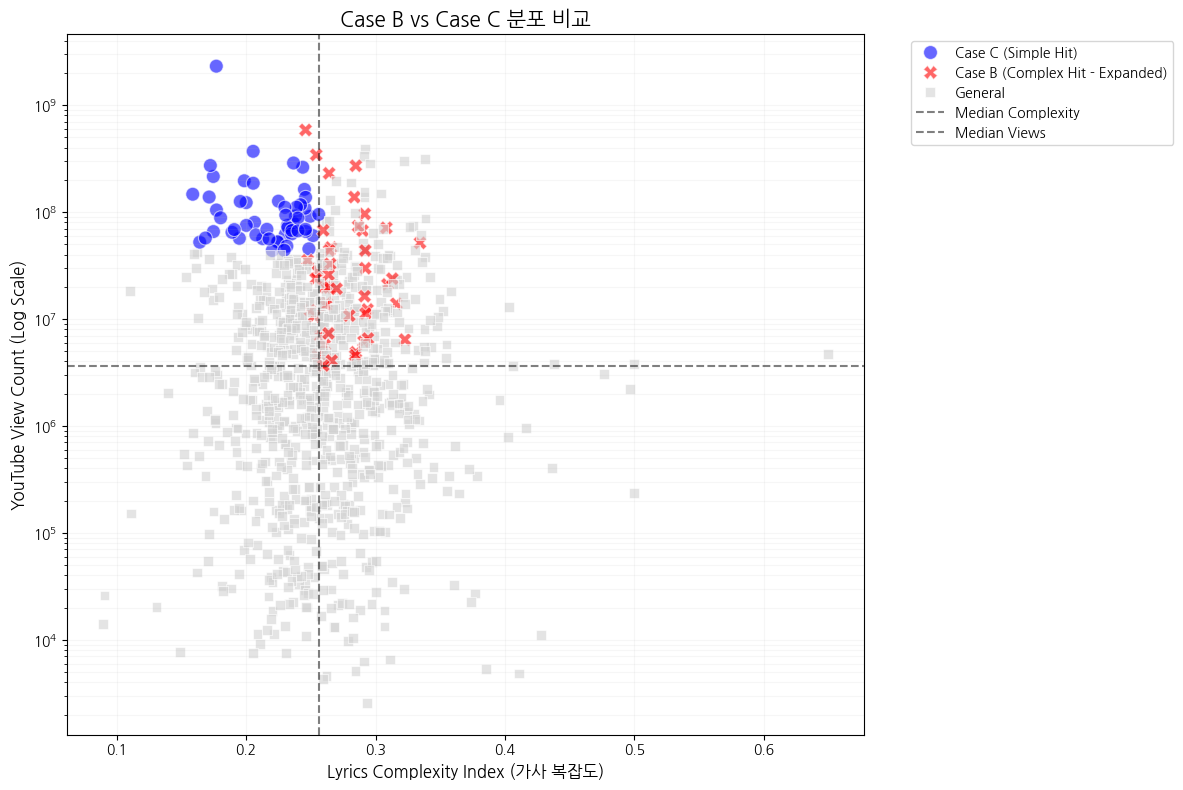

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 시각화를 위한 그룹 레이블링 업데이트 (확장된 Case B 적용)
df_final['group_expanded'] = 'General'
df_final.loc[case_c_simple_hit.index, 'group_expanded'] = 'Case C (Simple Hit)'
df_final.loc[dance_case_expanded.index, 'group_expanded'] = 'Case B (Complex Hit - Expanded)'

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_final,
    x='lyrics_complexity_index',
    y='api_view_count',
    hue='group_expanded',
    style='group_expanded',
    palette={'General': 'lightgrey', 'Case C (Simple Hit)': 'blue', 'Case B (Complex Hit - Expanded)': 'red'},
    alpha=0.6, s=100
)

# 기준선 표시 (중앙값)
plt.axvline(median_complexity, color='black', linestyle='--', alpha=0.5, label='Median Complexity')
plt.axhline(median_views, color='black', linestyle='--', alpha=0.5, label='Median Views')

plt.yscale('log')
plt.title('Case B vs Case C 분포 비교', fontsize=15)
plt.xlabel('Lyrics Complexity Index (가사 복잡도)', fontsize=12)
plt.ylabel('YouTube View Count (Log Scale)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.tight_layout()
plt.show()

### 1-7. Case B 확장 — 워드클라우드

**분석**: 확장된 Case B 그룹의 가사 워드클라우드.

In [ ]:
!pip install konlpy

📊 Case D (40곡) 순수 빈도 분석 결과


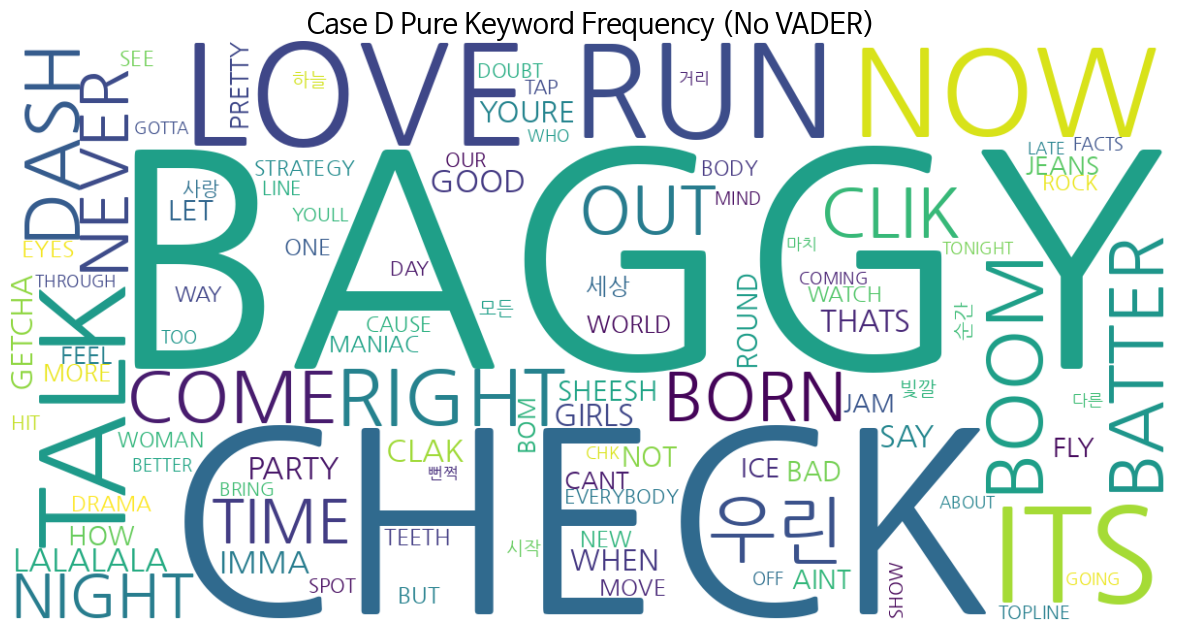

In [ ]:
from konlpy.tag import Okt
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

# 1. 준비: 형태소 분석기 및 데이터 로드
okt = Okt()

# Case D 데이터 (고조회 & 고복잡도) 추출
top_10_views_threshold = df_final['api_view_count'].quantile(0.9)
median_complexity = df_final['lyrics_complexity_index'].median()
case_d_complex_mega_hit = df_final[
    (df_final['api_view_count'] >= top_10_views_threshold) &
    (df_final['lyrics_complexity_index'] > median_complexity)
].copy()

def generate_case_d_noun_cloud(df_case):
    lyrics_list = df_case['genie_lyrics'].dropna().astype(str)

    # 순수하게 빈도 분석에서 제외할 불용어 (대명사, 조사 등)
    stop_words_kr = ['내게', '너를', '나를', '우리', '너의', '나의', '모두', '위해', '지금', '어디', '속에', '보고', '하나', '생각']
    stop_words_en = {
        'THE', 'AND', 'YOU', 'THAT', 'THIS', 'WITH', 'FOR', 'YOUR', 'WHAT', 'DONT', 'ARE', 'CAN',
        'GONNA', 'WANNA', 'YEAH', 'WOO', 'AHH', 'OHH', 'BABY', 'GIRL', 'BOY', 'LIKE', 'OOH',
        'BACK', 'DOWN', 'KNOW', 'MAKE', 'TAKE', 'WANT', 'FROM', 'THEY', 'THEM', 'GOT', 'GET',
        'READY', 'HERE', 'THERE', 'STOP', 'LOOK', 'LETS', 'SOME', 'STAY', 'HEY', 'JUST', 'ALL', 'WILL'
    }

    all_keywords = []

    for lyrics in lyrics_list:
        # --- [A] 한국어: Okt 명사 추출 ---
        kr_text = re.sub(r'[^가-힣\s]', '', lyrics)
        nouns = okt.nouns(kr_text)
        all_keywords.extend([n for n in nouns if len(n) > 1 and n not in stop_words_kr])

        # --- [B] 영어: 3글자 이상 일반 단어 추출 (VADER 필터링 없음) ---
        en_text = re.sub(r'[^a-zA-Z\s]', '', lyrics).upper()
        en_words = re.findall(r'\b[A-Z]{3,}\b', en_text)
        all_keywords.extend([w for w in en_words if w not in stop_words_en])

    # 2. 빈도수 계산
    counts = Counter(all_keywords)

    # 3. 워드클라우드 시각화
    if counts:
        print(f"📊 Case D ({len(df_case)}곡) 순수 빈도 분석 결과")
        wordcloud = WordCloud(
            font_path='NanumGothic', # 폰트 경로 확인 필요
            width=1200, height=600,
            background_color='white',
            colormap='viridis', # 시각적으로 깔끔한 컬러맵
            max_words=100
        ).generate_from_frequencies(counts)

        plt.figure(figsize=(15, 8))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title("Case D Pure Keyword Frequency (No VADER)", fontsize=20)
        plt.show()
    else:
        print("데이터가 부족합니다.")

# 실행
generate_case_d_noun_cloud(case_d_complex_mega_hit)

### 1-8. Case D 정의 (재정의: 복잡한 가사 + 메가히트)

**케이스 재정의**: 여기서부터 'Case D' = 조회수 상위 10% + 가사 복잡도 중앙값 초과 — 가사가 복잡한데도 메가히트한 그룹으로 재정의됩니다(앞선 idx104의 'Case D'와는 다른, 더 엄격한 정의).

In [ ]:
# Case C의 조회수 하한선(상위 10%)을 기준으로, 복잡도까지 높은 '최상위 복잡 성공군'을 찾아봅니다.
# Case C의 조회수 하한선 (상위 10%)
top_10_views = df_final['api_view_count'].quantile(0.9)
median_complexity = df_final['lyrics_complexity_index'].median()

# [Case D] 초고조회 + 고복잡도 (진짜 특이 케이스)
case_d_complex_mega_hit = df_final[
    (df_final['api_view_count'] >= top_10_views) &
    (df_final['lyrics_complexity_index'] > median_complexity)
].copy()

print(f"💎 [Case D] 가사는 복잡한데 조회수는 메가히트인 곡: {len(case_d_complex_mega_hit)}곡")
display(case_d_complex_mega_hit[['view_rank', 'songName', 'artists', 'api_view_count', 'lyrics_complexity_index']].sort_values('api_view_count', ascending=False))

💎 [Case D] 가사는 복잡한데 조회수는 메가히트인 곡: 40곡


,view_rank,songName,artists,api_view_count,lyrics_complexity_index
17,3,SHEESH,2543|BABYMONSTER (베이비몬스터)|BABYMONSTER|1,391040639,0.291771
25,6,BATTER UP,2543|BABYMONSTER (베이비몬스터)|BABYMONSTER|1,335144364,0.291120
28,7,락 (樂),377|Stray Kids (스트레이 키즈)|StrayKids|1,315388145,0.338360
41,8,특,377|Stray Kids (스트레이 키즈)|StrayKids|1,298130976,0.322017
31,10,Drama,2023|aespa|aespa|1,283557314,0.295589
37,12,3D (feat. Jack Harlow),410|정국|JUNGKOOK|1,270450262,0.284783
8,14,Mantra,682|제니 (JENNIE)|JENNIE|1,229896119,0.264158
19,17,Chk Chk Boom,377|Stray Kids (스트레이 키즈)|StrayKids|1,194509698,0.269371
18,18,New Woman (Feat. ROSALÍA),681|리사 (LISA)|LISA|1,188978749,0.280763
81,21,BOUNCY (K-HOT CHILLI PEPPERS),393|ATEEZ (에이티즈)|ATEEZ|1,154563847,0.291464


### 1-9. Case D — EDA

**분석**: Case D(복잡+메가히트)와 Case C(단순+히트)를 산점도로 비교.
**결과**: Case C는 '단순함'으로, Case D는 '밀도 높은 감정'으로 서로 다른 방식으로 대중성을 획득했다는 해석.

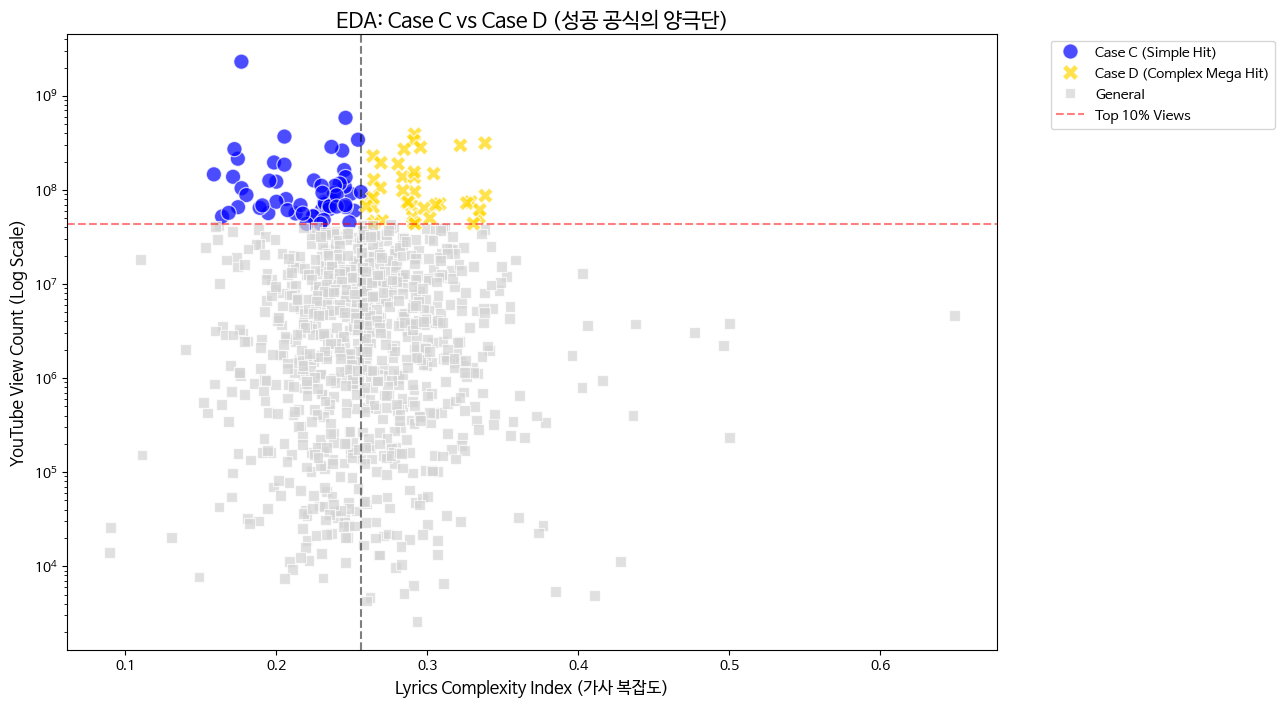

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 그룹 레이블링 업데이트
df_final['group_final'] = 'General'
df_final.loc[case_c_simple_hit.index, 'group_final'] = 'Case C (Simple Hit)'
df_final.loc[case_d_complex_mega_hit.index, 'group_final'] = 'Case D (Complex Mega Hit)'

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_final,
    x='lyrics_complexity_index',
    y='api_view_count',
    hue='group_final',
    style='group_final',
    palette={'General': 'lightgrey', 'Case C (Simple Hit)': 'blue', 'Case D (Complex Mega Hit)': 'gold'}, # Case D는 황금색으로 강조
    alpha=0.7, s=120
)

# 기준선 표시
plt.axvline(median_complexity, color='black', linestyle='--', alpha=0.5)
plt.axhline(df_final['api_view_count'].quantile(0.9), color='red', linestyle='--', alpha=0.5, label='Top 10% Views')

plt.yscale('log')
plt.title('EDA: Case C vs Case D (성공 공식의 양극단)', fontsize=15)
plt.xlabel('Lyrics Complexity Index (가사 복잡도)', fontsize=12)
plt.ylabel('YouTube View Count (Log Scale)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 1-10. Case D — 워드클라우드

**분석**: Case D 그룹의 가사 워드클라우드.

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


✅ Case D (40곡)의 감성 키워드 분석 중...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


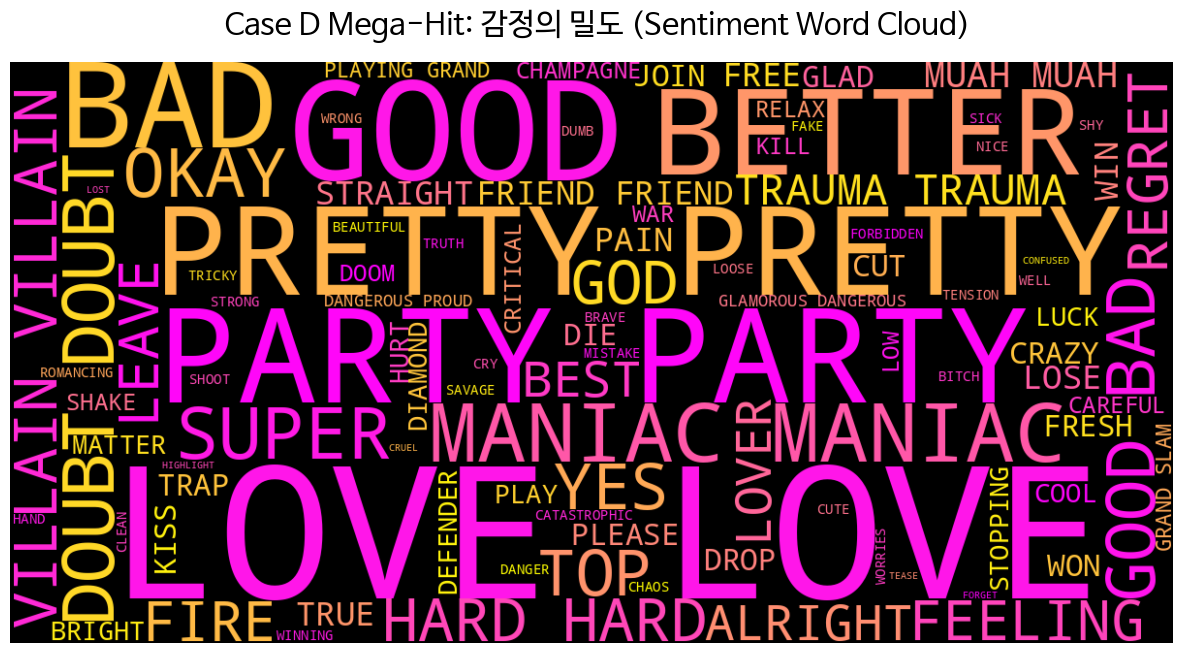


🏆 분석에 포함된 Case D 대표 곡:


,songName,artists,api_view_count,lyrics_complexity_index
17,SHEESH,2543|BABYMONSTER (베이비몬스터)|BABYMONSTER|1,391040639,0.291771
25,BATTER UP,2543|BABYMONSTER (베이비몬스터)|BABYMONSTER|1,335144364,0.291120
28,락 (樂),377|Stray Kids (스트레이 키즈)|StrayKids|1,315388145,0.338360
41,특,377|Stray Kids (스트레이 키즈)|StrayKids|1,298130976,0.322017
31,Drama,2023|aespa|aespa|1,283557314,0.295589
37,3D (feat. Jack Harlow),410|정국|JUNGKOOK|1,270450262,0.284783
8,Mantra,682|제니 (JENNIE)|JENNIE|1,229896119,0.264158
19,Chk Chk Boom,377|Stray Kids (스트레이 키즈)|StrayKids|1,194509698,0.269371
18,New Woman (Feat. ROSALÍA),681|리사 (LISA)|LISA|1,188978749,0.280763
81,BOUNCY (K-HOT CHILLI PEPPERS),393|ATEEZ (에이티즈)|ATEEZ|1,154563847,0.291464


In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

# 1. 환경 및 데이터 준비
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# Case D 재추출 (분석의 연속성을 위해 기준 재설정)
top_10_views_threshold = df_final['api_view_count'].quantile(0.9)
median_complexity = df_final['lyrics_complexity_index'].median()

case_d_complex_mega_hit = df_final[
    (df_final['api_view_count'] >= top_10_views_threshold) &
    (df_final['lyrics_complexity_index'] > median_complexity)
].copy()

# 2. 불용어 및 감성 사전 설정
vader_lexicon = sia.lexicon.keys()
stop_words_en = {
    'THE', 'AND', 'YOU', 'THAT', 'THIS', 'WITH', 'FOR', 'YOUR', 'WHAT', 'DONT', 'ARE', 'CAN',
    'GONNA', 'WANNA', 'YEAH', 'WOO', 'AHH', 'OHH', 'BABY', 'GIRL', 'BOY', 'LIKE', 'OOH',
    'BACK', 'DOWN', 'KNOW', 'MAKE', 'TAKE', 'WANT', 'FROM', 'THEY', 'THEM', 'GOT', 'GET',
    'READY', 'HERE', 'THERE', 'STOP', 'LOOK', 'LETS', 'SOME', 'STAY', 'HEY', 'JUST', 'ALL', 'WILL'
}

# 3. 텍스트 처리 (오류 방지를 위해 문자열 결합 후 대문자 변환)
# .str.upper() 대신 전체를 합친 뒤 처리하는 방식이 더 안전합니다.
all_lyrics_text = " ".join(case_d_complex_mega_hit['genie_lyrics'].astype(str)).upper()
words = re.findall(r'\b[A-Z]{3,}\b', all_lyrics_text)

# VADER 사전에 있는 감정 단어만 필터링
sentiment_words = [w for w in words if w.lower() in vader_lexicon and w not in stop_words_en]

# 4. 시각화
if sentiment_words:
    print(f"✅ Case D ({len(case_d_complex_mega_hit)}곡)의 감성 키워드 분석 중...")

    wordcloud = WordCloud(
        width=1200, height=600,
        background_color='black', # 강렬한 감성 대비를 위해 블랙 배경
        colormap='spring',       # 메가히트의 화려함을 상징하는 핑크/옐로우 톤
        max_words=100,
        random_state=42
    ).generate(" ".join(sentiment_words))

    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("🔥 Case D Mega-Hit: 감정의 밀도 (Sentiment Word Cloud)", fontsize=22, pad=20)
    plt.show()

    # 데이터 확인용 상위 곡 리스트 출력
    print("\n🏆 분석에 포함된 Case D 대표 곡:")
    display(case_d_complex_mega_hit[['songName', 'artists', 'api_view_count', 'lyrics_complexity_index']].sort_values('api_view_count', ascending=False).head(10))
else:
    print("❌ 추출된 감성 단어가 없습니다. 데이터의 가사 컬럼을 확인해주세요.")

### 1-11. Case D — VADER 감성분석

**분석**: Case D 곡들에 영어 기반 VADER 감성분석(`vader_score`)을 적용.
**결과**: 극단적 긍정군(Love wins all, Mantra, Party O'Clock 등)과 극단적 부정군(DASH, BADVILLAIN 등)으로 뚜렷하게 양분됨 → Case D는 가사가 많을 뿐 아니라 감정의 진폭을 강하게 쏟아내는 '감정 양극화' 전략을 취한다는 해석.

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# VADER 사전 다운로드
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

def analyze_vader_sentiment(df):
    # 영어 가사(또는 혼용 가사)에 대해 감성 점수 계산
    df['vader_score'] = df['genie_lyrics'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
    return df

# Case D 곡들에 대해 감성 분석 실행
case_d_sentiment = analyze_vader_sentiment(case_d_complex_mega_hit)

print("🚀 [Case D 곡들의 감성 분석 결과 (VADER)]")
# vader_score: 1에 가까울수록 극단적 긍정, -1에 가까울수록 극단적 부정
display(case_d_sentiment[['songName', 'artists', 'vader_score', 'lyrics_complexity_index']].sort_values('vader_score', ascending=False))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


🚀 [Case D 곡들의 감성 분석 결과 (VADER)]


,songName,artists,vader_score,lyrics_complexity_index
74,Love wins all,385|아이유|IU|1,0.9982,0.269003
8,Mantra,682|제니 (JENNIE)|JENNIE|1,0.9975,0.264158
136,BONA BONA,1744|TREASURE (트레저)|TREASURE|1,0.9972,0.287501
150,Party O'Clock,2298|NMIXX|NMIXX|1,0.9966,0.259657
37,3D (feat. Jack Harlow),410|정국|JUNGKOOK|1,0.9966,0.284783
52,Super Lady,361|i-dle (아이들)|idle|1,0.9949,0.291503
105,HEARTRIS,2765|NiziU (니쥬)|NiziU|0,0.9947,0.264235
41,특,377|Stray Kids (스트레이 키즈)|StrayKids|1,0.9942,0.322017
82,Cosmic,316|Red Velvet (레드벨벳)|RedVelvet|1,0.9931,0.290455
126,TOPLINE (Feat. Tiger JK),377|Stray Kids (스트레이 키즈)|StrayKids|1,0.9925,0.338567


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


✅ 분석 대상 (Case D) 곡 수: 40곡


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


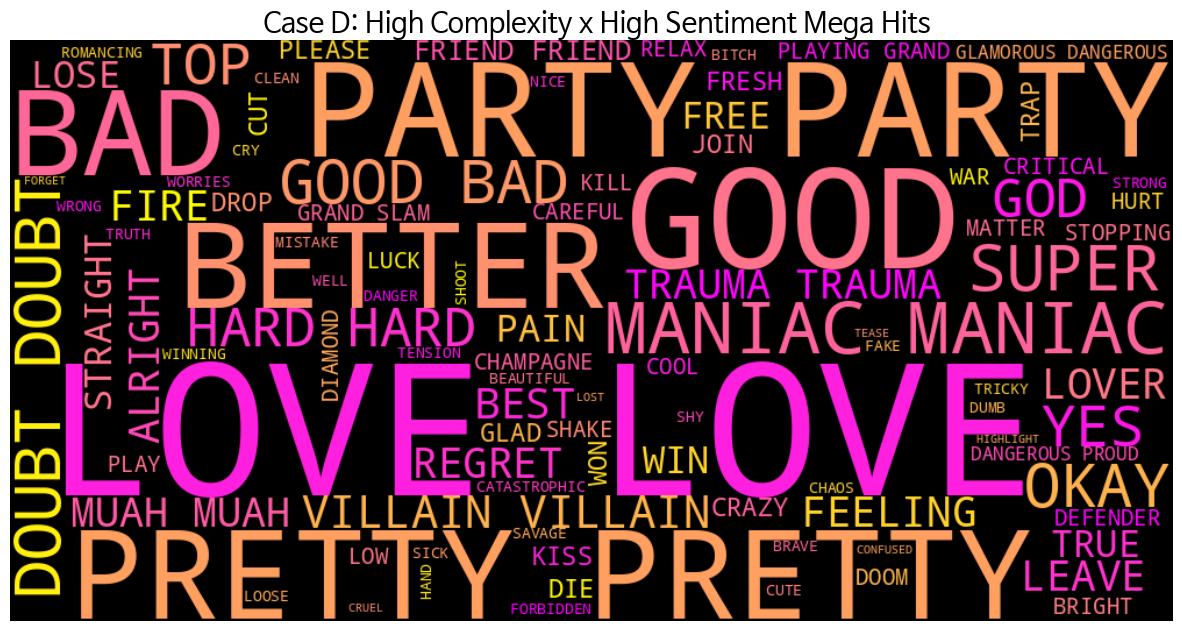


🏆 Case D 내 조회수 상위 5곡:


,songName,artists,api_view_count,lyrics_complexity_index
17,SHEESH,2543|BABYMONSTER (베이비몬스터)|BABYMONSTER|1,391040639,0.291771
25,BATTER UP,2543|BABYMONSTER (베이비몬스터)|BABYMONSTER|1,335144364,0.291120
28,락 (樂),377|Stray Kids (스트레이 키즈)|StrayKids|1,315388145,0.338360
41,특,377|Stray Kids (스트레이 키즈)|StrayKids|1,298130976,0.322017
31,Drama,2023|aespa|aespa|1,283557314,0.295589


In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

# 0. 데이터 추출 (Case D: 고조회 & 고복잡도)
# 전체 데이터(df_final)에서 상위 10% 조회수와 중앙값 이상의 복잡도를 가진 곡 추출
top_10_views_threshold = df_final['api_view_count'].quantile(0.9)
median_complexity = df_final['lyrics_complexity_index'].median()

case_d_complex_mega_hit = df_final[
    (df_final['api_view_count'] >= top_10_views_threshold) &
    (df_final['lyrics_complexity_index'] > median_complexity)
].copy()

# 1. VADER 분석기 및 필수 리소스 준비
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()
vader_lexicon = sia.lexicon.keys()

# 2. 불용어 리스트 (의성어 및 무의미한 단어 제거)
stop_words_en = {
    'THE', 'AND', 'YOU', 'THAT', 'THIS', 'WITH', 'FOR', 'YOUR', 'WHAT', 'DONT', 'ARE', 'CAN',
    'GONNA', 'WANNA', 'YEAH', 'WOO', 'AHH', 'OHH', 'BABY', 'GIRL', 'BOY', 'LIKE', 'OOH', 'AHH',
    'BACK', 'DOWN', 'KNOW', 'MAKE', 'TAKE', 'WANT', 'FROM', 'THEY', 'THEM', 'GOT', 'GET',
    'READY', 'HERE', 'THERE', 'STOP', 'LOOK', 'LETS', 'SOME', 'STAY', 'HEY', 'JUST', 'ALL', 'WILL'
}

# 3. 가사 전처리 및 감성 단어 추출
# 모든 가사를 하나의 대문자 텍스트로 합침
all_lyrics_text = " ".join(case_d_complex_mega_hit['genie_lyrics'].astype(str)).upper()

# 영문 단어 추출 (3글자 이상)
words = re.findall(r'\b[A-Z]{3,}\b', all_lyrics_text)

# VADER 사전에 있으면서 불용어가 아닌 '감정 단어'만 필터링
sentiment_words = [w for w in words if w.lower() in vader_lexicon and w not in stop_words_en]

# 4. 결과 출력 및 시각화
print(f"✅ 분석 대상 (Case D) 곡 수: {len(case_d_complex_mega_hit)}곡")

if sentiment_words:
    cloud_text = " ".join(sentiment_words)

    wordcloud = WordCloud(
        width=1000, height=500,
        background_color='black',
        colormap='spring', # 화려한 성공의 색상
        max_words=100
    ).generate(cloud_text)

    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("🔥 Case D: High Complexity x High Sentiment Mega Hits", fontsize=20)
    plt.show()

    # 끝판왕 곡 상세 정보 확인
    print("\n🏆 Case D 내 조회수 상위 5곡:")
    display(case_d_complex_mega_hit[['songName', 'artists', 'api_view_count', 'lyrics_complexity_index']].sort_values('api_view_count', ascending=False).head(5))
else:
    print("❌ 감성 단어가 추출되지 않았습니다. 데이터프레임의 'genie_lyrics' 컬럼을 확인해주세요.")

### 1-12. Case A 추출 (발라드 + 단순 + 저조회)

**분석**: Case A(발라드+저복잡도+저조회) 대상 곡 리스트를 추출.

In [ ]:
# Case A 추출 (발라드 + 낮은 복잡도 + 낮은 조회수)
median_views = df_final['api_view_count'].median()
median_complexity = df_final['lyrics_complexity_index'].median()

case_a_ballad_low = df_final[
    (df_final['genie_genre'].str.contains('발라드', na=False)) &
    (df_final['lyrics_complexity_index'] < median_complexity) &
    (df_final['api_view_count'] < median_views)
].copy()

print(f"📊 [Case A] 분석 대상: {len(case_a_ballad_low)}곡")
display(case_a_ballad_low[['view_rank', 'songName', 'artists', 'api_view_count', 'lyrics_complexity_index']].sort_values('api_view_count').head(10))

📊 [Case A] 분석 대상: 44곡


,view_rank,songName,artists,api_view_count,lyrics_complexity_index
947,944,조금만 더 너를,1465|정인|jungin|1,7462,0.205598
945,942,I Remember,2420|신현희||0,7665,0.148928
939,936,이별을 배웠어 (Always In My Heart),"915|소연 (LABOUM)|SOYEON|0,2798|현오||0",11279,0.208880
774,930,바람에 실어,1333|장혜진||0,13527,0.230226
879,919,발걸음 (Steps Forward),772|니엘 (틴탑) |NIEL|1,20305,0.246166
902,905,영원히 영원히,2045|길구봉구||0,27186,0.247687
920,903,이 별,1516|유성은||0,28342,0.182337
656,893,서있을게(Down for you),1632|GHOST9|GHOST9|1,34177,0.245466
862,887,Dance with me,838|정예인 (Yein)|Yein|1,38633,0.252920
913,883,장마,1461|박보람|ParkBoRam|1,41076,0.194515


### 1-13. Case A — 위치 EDA

**분석**: Case A를 전체 분포(복잡도×조회수) 산점도 상에서 위치 확인.
**결과**: 왼쪽 하단(저복잡도·저조회)에 몰려있음 → "가사가 단순해도 장르·아티스트 파워가 약하면 성공하기 어렵다"는 해석.

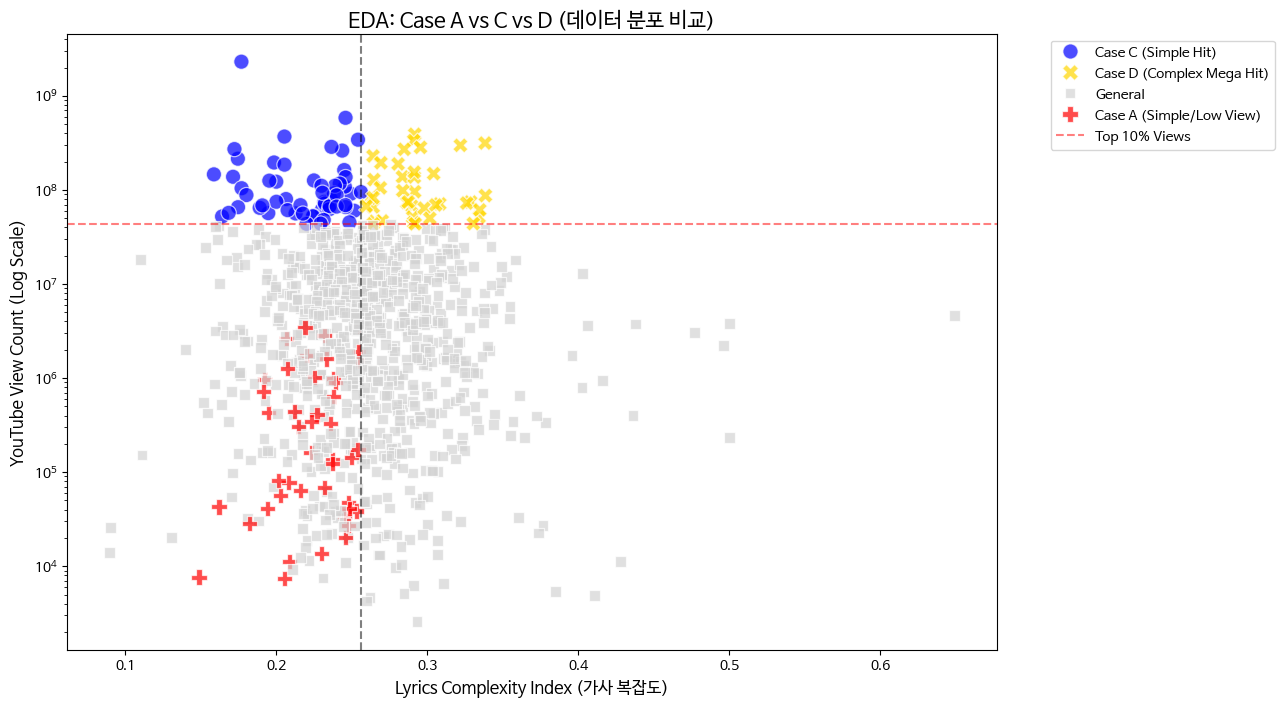

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 그룹 레이블링 업데이트
df_final['group_final'] = 'General'
df_final.loc[case_c_simple_hit.index, 'group_final'] = 'Case C (Simple Hit)'
df_final.loc[case_d_complex_mega_hit.index, 'group_final'] = 'Case D (Complex Mega Hit)'
df_final.loc[case_a_ballad_low.index, 'group_final'] = 'Case A (Simple/Low View)'

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_final,
    x='lyrics_complexity_index',
    y='api_view_count',
    hue='group_final',
    style='group_final',
    palette={
        'General': 'lightgrey',
        'Case C (Simple Hit)': 'blue',
        'Case D (Complex Mega Hit)': 'gold',
        'Case A (Simple/Low View)': 'red' # Case A는 빨간색으로 표시
    },
    alpha=0.7, s=120
)

# 기준선 표시
plt.axvline(median_complexity, color='black', linestyle='--', alpha=0.5)
plt.axhline(df_final['api_view_count'].quantile(0.9), color='red', linestyle='--', alpha=0.5, label='Top 10% Views')

plt.yscale('log')
plt.title('EDA: Case A vs C vs D (데이터 분포 비교)', fontsize=15)
plt.xlabel('Lyrics Complexity Index (가사 복잡도)', fontsize=12)
plt.ylabel('YouTube View Count (Log Scale)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

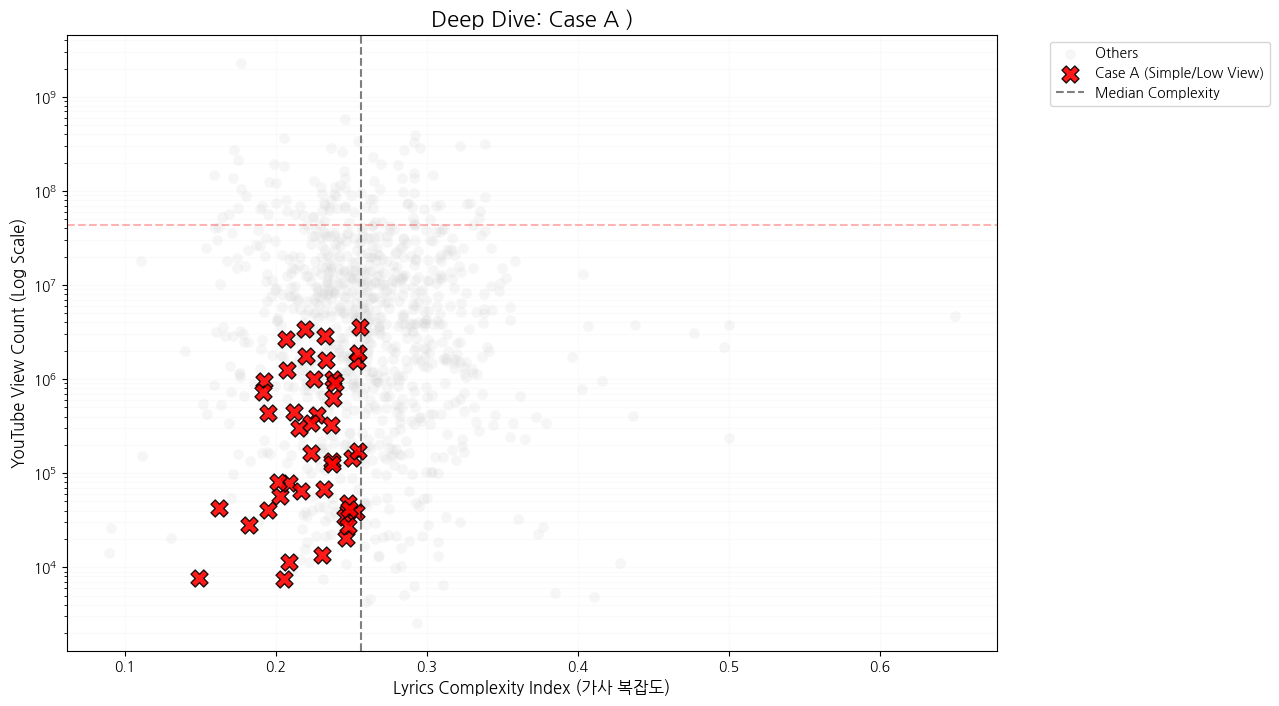

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 시각화를 위한 필터링 (Case A만 강조)
plt.figure(figsize=(12, 8))

# 1. 배경: 전체 데이터 (연한 회색으로 처리하여 분포만 확인)
sns.scatterplot(
    data=df_final[df_final['group_final'] != 'Case A (Simple/Low View)'],
    x='lyrics_complexity_index',
    y='api_view_count',
    color='lightgrey',
    alpha=0.2, s=60, label='Others'
)

# 2. 강조: Case A (단순/저조회수 그룹)
sns.scatterplot(
    data=df_final[df_final['group_final'] == 'Case A (Simple/Low View)'],
    x='lyrics_complexity_index',
    y='api_view_count',
    color='red',
    alpha=0.9, s=150, edgecolor='black', marker='X',
    label='Case A (Simple/Low View)'
)

# 기준선 표시 (중앙값 및 상위 10%선)
plt.axvline(median_complexity, color='black', linestyle='--', alpha=0.5, label='Median Complexity')
plt.axhline(df_final['api_view_count'].quantile(0.9), color='red', linestyle='--', alpha=0.3)

plt.yscale('log')
plt.title('Deep Dive: Case A )', fontsize=16)
plt.xlabel('Lyrics Complexity Index (가사 복잡도)', fontsize=12)
plt.ylabel('YouTube View Count (Log Scale)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.05)
plt.show()

### 1-14. Case A — 워드클라우드

**분석**: Case A 그룹의 가사 워드클라우드.

📊 [Case A] 발라드 (44곡) 키워드 빈도 분석


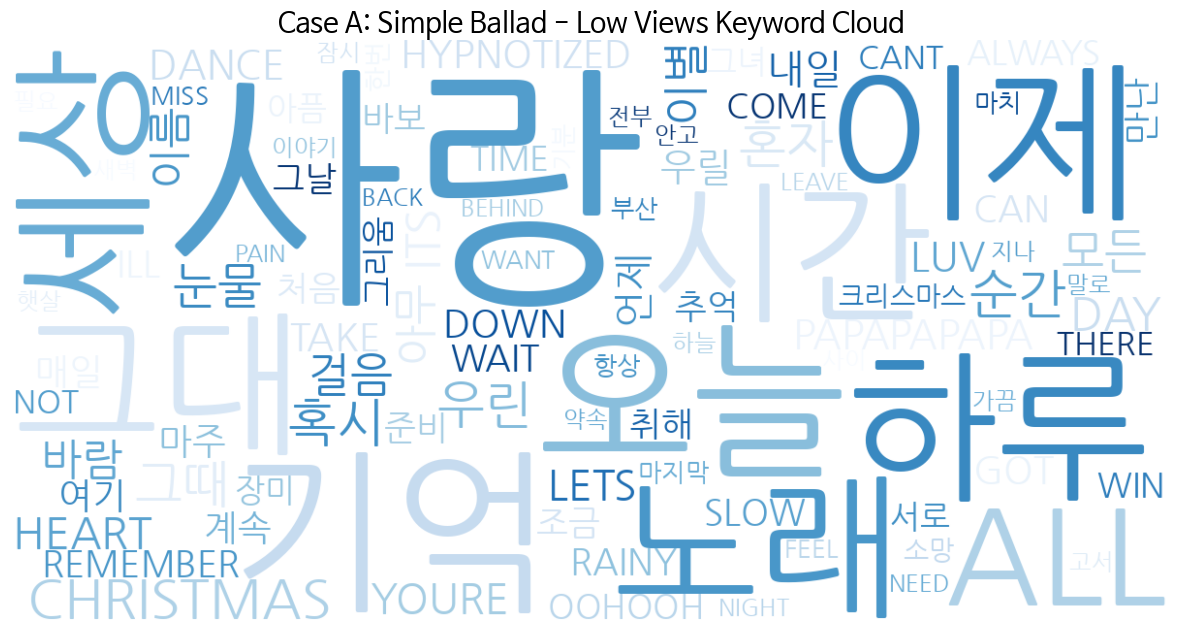

In [ ]:
from konlpy.tag import Okt
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

# 1. 준비: 형태소 분석기 및 데이터 로드
okt = Okt()

# [Case A] 추출: 발라드 장르 & 낮은 복잡도 & 낮은 조회수
# (사용자님의 기존 필터링 결과인 44곡 데이터를 사용합니다)
median_views = df_final['api_view_count'].median()
median_complexity = df_final['lyrics_complexity_index'].median()

case_a_ballad_low = df_final[
    (df_final['genie_genre'].str.contains('발라드', na=False)) &
    (df_final['lyrics_complexity_index'] < median_complexity) &
    (df_final['api_view_count'] < median_views)
].copy()

def generate_case_a_noun_cloud(df_case):
    lyrics_list = df_case['genie_lyrics'].dropna().astype(str)

    # 발라드 특유의 감성어 중 분석 가치가 낮은 단어 제외
    stop_words_kr = [
        '내게', '너를', '나를', '우리', '너의', '나의', '모두', '위해', '지금', '어디',
        '속에', '보고', '하나', '생각', '모습', '다시', '그저', '마음', '사람'
    ]
    stop_words_en = {
        'THE', 'AND', 'YOU', 'THAT', 'THIS', 'WITH', 'FOR', 'YOUR', 'WHAT', 'DONT',
        'YEAH', 'OHH', 'AHH', 'BABY', 'KNOW', 'MAKE', 'LIKE', 'JUST', 'LOVE'
    }

    all_keywords = []

    for lyrics in lyrics_list:
        # --- [A] 한국어: Okt 명사 추출 ---
        kr_text = re.sub(r'[^가-힣\s]', '', lyrics)
        nouns = okt.nouns(kr_text)
        all_keywords.extend([n for n in nouns if len(n) > 1 and n not in stop_words_kr])

        # --- [B] 영어: 3글자 이상 일반 단어 추출 ---
        en_text = re.sub(r'[^a-zA-Z\s]', '', lyrics).upper()
        en_words = re.findall(r'\b[A-Z]{3,}\b', en_text)
        all_keywords.extend([w for w in en_words if w not in stop_words_en])

    # 2. 빈도수 계산
    counts = Counter(all_keywords)

    # 3. 워드클라우드 시각화
    if counts:
        print(f"📊 [Case A] 발라드 ({len(df_case)}곡) 키워드 빈도 분석")
        wordcloud = WordCloud(
            font_path='NanumGothic',
            width=1200, height=600,
            background_color='white',
            colormap='Blues', # 발라드의 차분한 느낌을 위한 블루톤
            max_words=100
        ).generate_from_frequencies(counts)

        plt.figure(figsize=(15, 8))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title("Case A: Simple Ballad - Low Views Keyword Cloud", fontsize=20)
        plt.show()
    else:
        print("데이터가 부족합니다.")

# 실행
generate_case_a_noun_cloud(case_a_ballad_low)

### 1-15. Case A — VADER 클라우드

**분석**: Case A 가사에 VADER 감성 어휘 기반 워드클라우드 적용.

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128148 (\N{BROKEN HEART}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


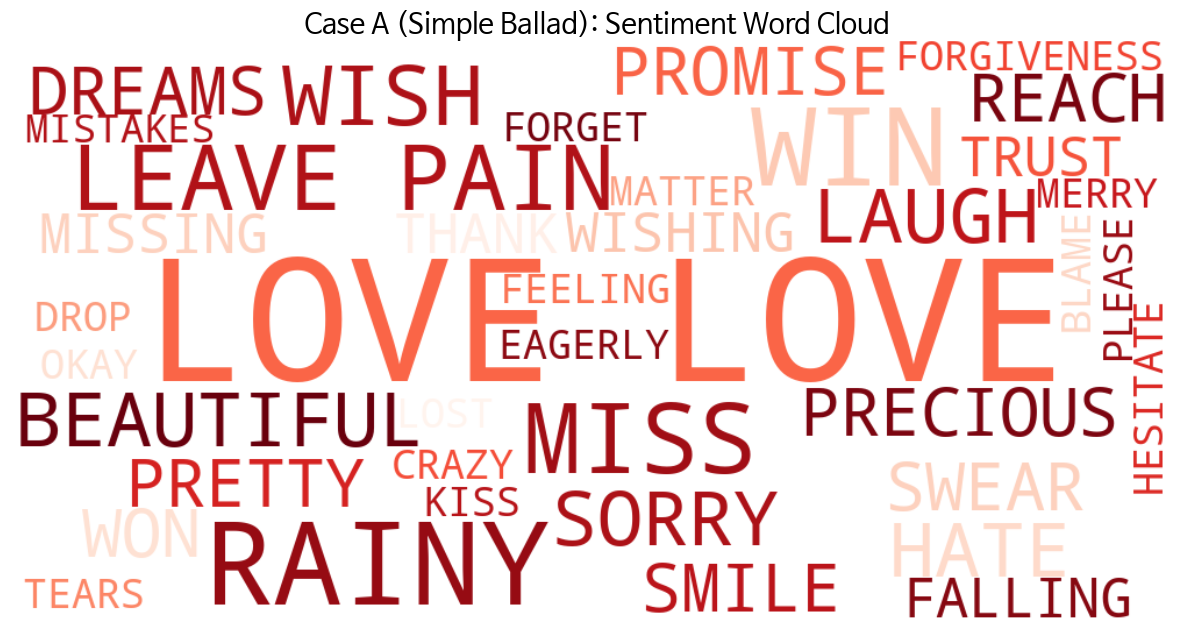

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import re

# VADER 준비
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()
vader_lexicon = sia.lexicon.keys()

# Case A 가사 전처리
all_lyrics_text_a = " ".join(case_a_ballad_low['genie_lyrics'].astype(str)).upper()
words_a = re.findall(r'\b[A-Z]{3,}\b', all_lyrics_text_a)

# VADER 감성 단어 필터링 (불용어 제외)
sentiment_words_a = [w for w in words_a if w.lower() in vader_lexicon and w not in stop_words_en]

if sentiment_words_a:
    wordcloud_a = WordCloud(
        width=1000, height=500,
        background_color='white',
        colormap='Reds', # 낮은 조회수의 경고 혹은 차분한 감성
        max_words=100
    ).generate(" ".join(sentiment_words_a))

    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud_a, interpolation='bilinear')
    plt.axis('off')
    plt.title("💔 Case A (Simple Ballad): Sentiment Word Cloud", fontsize=20)
    plt.show()
else:
    print("추출된 감성 단어가 없습니다. 영문 가사 비중이 너무 낮을 수 있습니다.")

### 1-16. Case E 정의 (단순 가사 + 대박 발라드)

**케이스 정의**: Case E = 발라드 + 가사 복잡도 하위 50% + 조회수 상위 20% — 가사는 단순한데 크게 흥행한 발라드.
**결과**: 가사가 단순하면 리스너가 가사 해석에 에너지를 쓸 필요가 없어, 그 여유가 아티스트의 목소리(감성)에 집중되며 조회수로 이어진다는 해석.

In [ ]:
# [Case E] 가사 단순(하위 50%) & 고조회(상위 20%) 발라드
views_top_20 = df_final['api_view_count'].quantile(0.8)
median_complexity = df_final['lyrics_complexity_index'].median()

case_e_simple_mega_ballad = df_final[
    (df_final['genie_genre'].str.contains('발라드', na=False)) &
    (df_final['lyrics_complexity_index'] < median_complexity) &
    (df_final['api_view_count'] >= views_top_20)
].copy()

print(f"💎 [Case E] '단순함의 미학'으로 성공한 발라드: {len(case_e_simple_mega_ballad)}곡")
display(case_e_simple_mega_ballad[['view_rank', 'songName', 'artists', 'api_view_count', 'lyrics_complexity_index']].sort_values('api_view_count', ascending=False))

💎 [Case E] '단순함의 미학'으로 성공한 발라드: 3곡


,view_rank,songName,artists,api_view_count,lyrics_complexity_index
7,24,number one girl,684|로제 (ROSÉ)|ROSE|1,138041277,0.171498
50,26,Stuck In The Middle,2543|BABYMONSTER (베이비몬스터)|BABYMONSTER|1,137055446,0.245996
114,69,Hate You,410|정국|JUNGKOOK|1,65607488,0.174817


### 1-17. Case E 확장 (모수 늘리기)

**분석**: 기준을 완화(조회수 상위 40%, 복잡도 중앙값 미만)해 Case E 표본을 확장.

In [ ]:
# 기준 완화: 조회수 상위 40% 이상 & 복잡도 중앙값 미만 발라드
views_threshold_relaxed = df_final['api_view_count'].quantile(0.6) # 상위 40%
median_complexity = df_final['lyrics_complexity_index'].median()

case_e_expanded = df_final[
    (df_final['genie_genre'].str.contains('발라드', na=False)) &
    (df_final['lyrics_complexity_index'] < median_complexity) &
    (df_final['api_view_count'] >= views_threshold_relaxed)
].copy()

print(f"💎 [Case E] 확장된 단순 대박 발라드: {len(case_e_expanded)}곡")
display(case_e_expanded[['view_rank', 'songName', 'artists', 'api_view_count', 'lyrics_complexity_index']].sort_values('api_view_count', ascending=False).head(15))

💎 [Case E] 확장된 단순 대박 발라드: 8곡


,view_rank,songName,artists,api_view_count,lyrics_complexity_index
7,24,number one girl,684|로제 (ROSÉ)|ROSE|1,138041277,0.171498
50,26,Stuck In The Middle,2543|BABYMONSTER (베이비몬스터)|BABYMONSTER|1,137055446,0.245996
114,69,Hate You,410|정국|JUNGKOOK|1,65607488,0.174817
268,211,Everything (종호),393|ATEEZ (에이티즈)|ATEEZ|1,17077696,0.250968
291,304,Mars,398|디오(D.O.) |D.O.|1,10347711,0.240957
48,313,When You Say My Name,2564|FIFTY FIFTY|FIFTYFIFTY|1,9476701,0.210216
357,330,봄이 와도,1126|로이킴|RoyKim|1,8551710,0.237366
410,375,Falling Slowly,731|대성|DAESUNG|1,6551134,0.233119


### 1-18. Case E 확장 — 위치 EDA

**분석**: 확장된 Case E를 전체 분포 산점도 상에서 위치 확인.

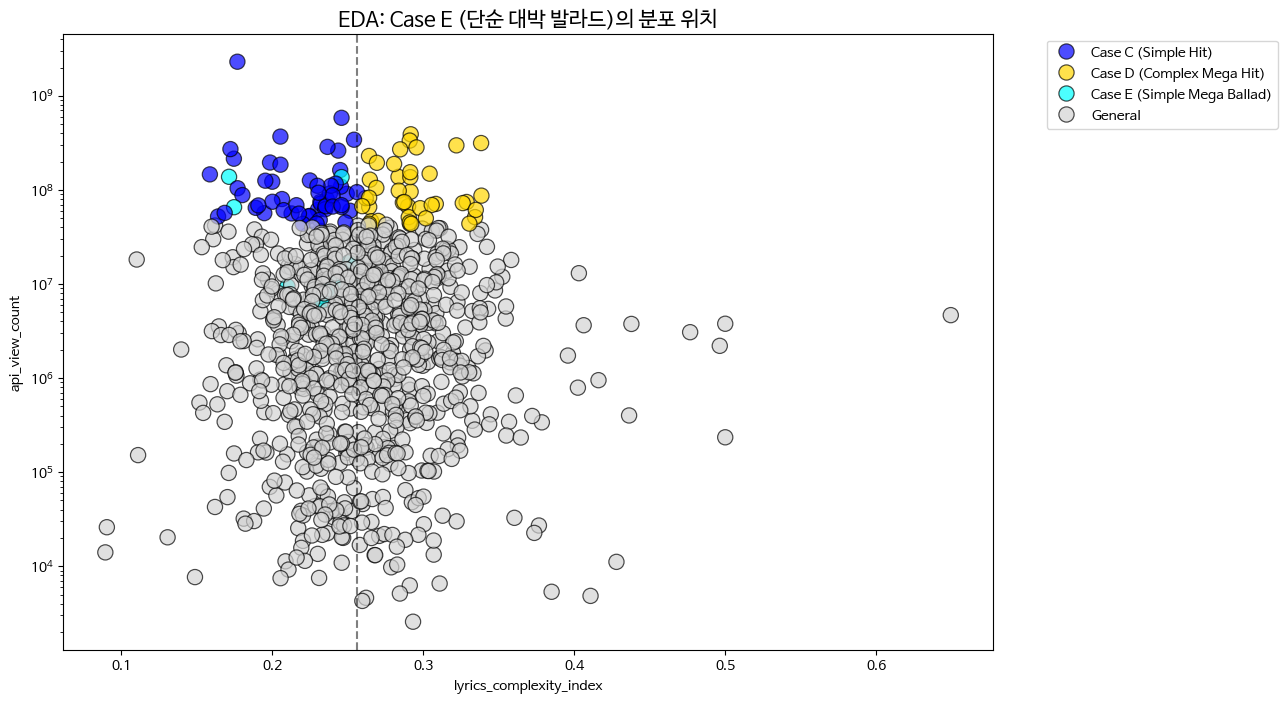

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 그룹 레이블링 업데이트 (Case E 포함)
df_final['group_final'] = 'General'
df_final.loc[case_c_simple_hit.index, 'group_final'] = 'Case C (Simple Hit)'
df_final.loc[case_d_complex_mega_hit.index, 'group_final'] = 'Case D (Complex Mega Hit)'
df_final.loc[case_e_expanded.index, 'group_final'] = 'Case E (Simple Mega Ballad)'

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_final,
    x='lyrics_complexity_index',
    y='api_view_count',
    hue='group_final',
    palette={
        'General': 'lightgrey',
        'Case C (Simple Hit)': 'blue',
        'Case D (Complex Mega Hit)': 'gold',
        'Case E (Simple Mega Ballad)': 'cyan' # Case E는 하늘색
    },
    alpha=0.7, s=120, edgecolor='black'
)

plt.axvline(median_complexity, color='black', linestyle='--', alpha=0.5)
plt.yscale('log')
plt.title('EDA: Case E (단순 대박 발라드)의 분포 위치', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 1-19. Case E 재정의 (단어 수 기준으로 모수 확대)

**분석**: 복잡도 지수 대신 순수 단어 수(`lyrics_word_count`) 기준으로 Case E를 재정의(조회수 중앙값 이상 + 단어수 중앙값 이하)해 표본을 더 늘림.
**결과**: 발라드의 '미니멀리즘'을 판별할 땐 어휘 다양성보다 '가사 총량(여백)'이 더 정확한 기준이라는 결론.

In [ ]:
# 기준을 조금 더 너그럽게 조정
# 조회수 상위 50%(중앙값) 이상 & 단어 수 하위 50%(중앙값) 이하 발라드
word_count_mid = df_final['lyrics_word_count'].median()
views_mid = df_final['api_view_count'].median()

case_e_final_push = df_final[
    (df_final['genie_genre'].str.contains('발라드', na=False)) &
    (df_final['lyrics_word_count'] <= word_count_mid) &
    (df_final['api_view_count'] >= views_mid)
].copy()

print(f"✅ 최종 조정된 Case E 곡 수: {len(case_e_final_push)}곡")
# 리스트 확인
display(case_e_final_push[['songName', 'artists', 'lyrics_word_count', 'api_view_count']].sort_values('api_view_count', ascending=False).head(20))

✅ 최종 조정된 Case E 곡 수: 17곡


,songName,artists,lyrics_word_count,api_view_count
74,Love wins all,385|아이유|IU|1,163,105212861
114,Hate You,410|정국|JUNGKOOK|1,164,65607488
317,Let Me In,272|EXO|EXO|1,244,21171432
268,Everything (종호),393|ATEEZ (에이티즈)|ATEEZ|1,138,17077696
291,Mars,398|디오(D.O.) |D.O.|1,195,10347711
48,When You Say My Name,2564|FIFTY FIFTY|FIFTYFIFTY|1,259,9476701
432,별 떨어진다 (I Do),398|디오(D.O.) |D.O.|1,212,9438226
275,내게 어울릴 이별 노래가 없어 (Prod. 윤상),1118|케이윌|K.will|1,111,9293115
357,봄이 와도,1126|로이킴|RoyKim|1,155,8551710
410,Falling Slowly,731|대성|DAESUNG|1,172,6551134


### 1-20. Case E 재정의 — EDA

**분석**: 확장된 Case E(단어수 기준) 시각화 및 대표곡 확인.
**결과**: 아이유 'Love wins all', 정국 'Hate You' 같은 슈퍼스타 곡은 최상위 대박, 나머지 곡들은 중박 수준 → 아티스트 파워와 별개로 '가사 미니멀 전략' 자체는 공통적으로 나타남.

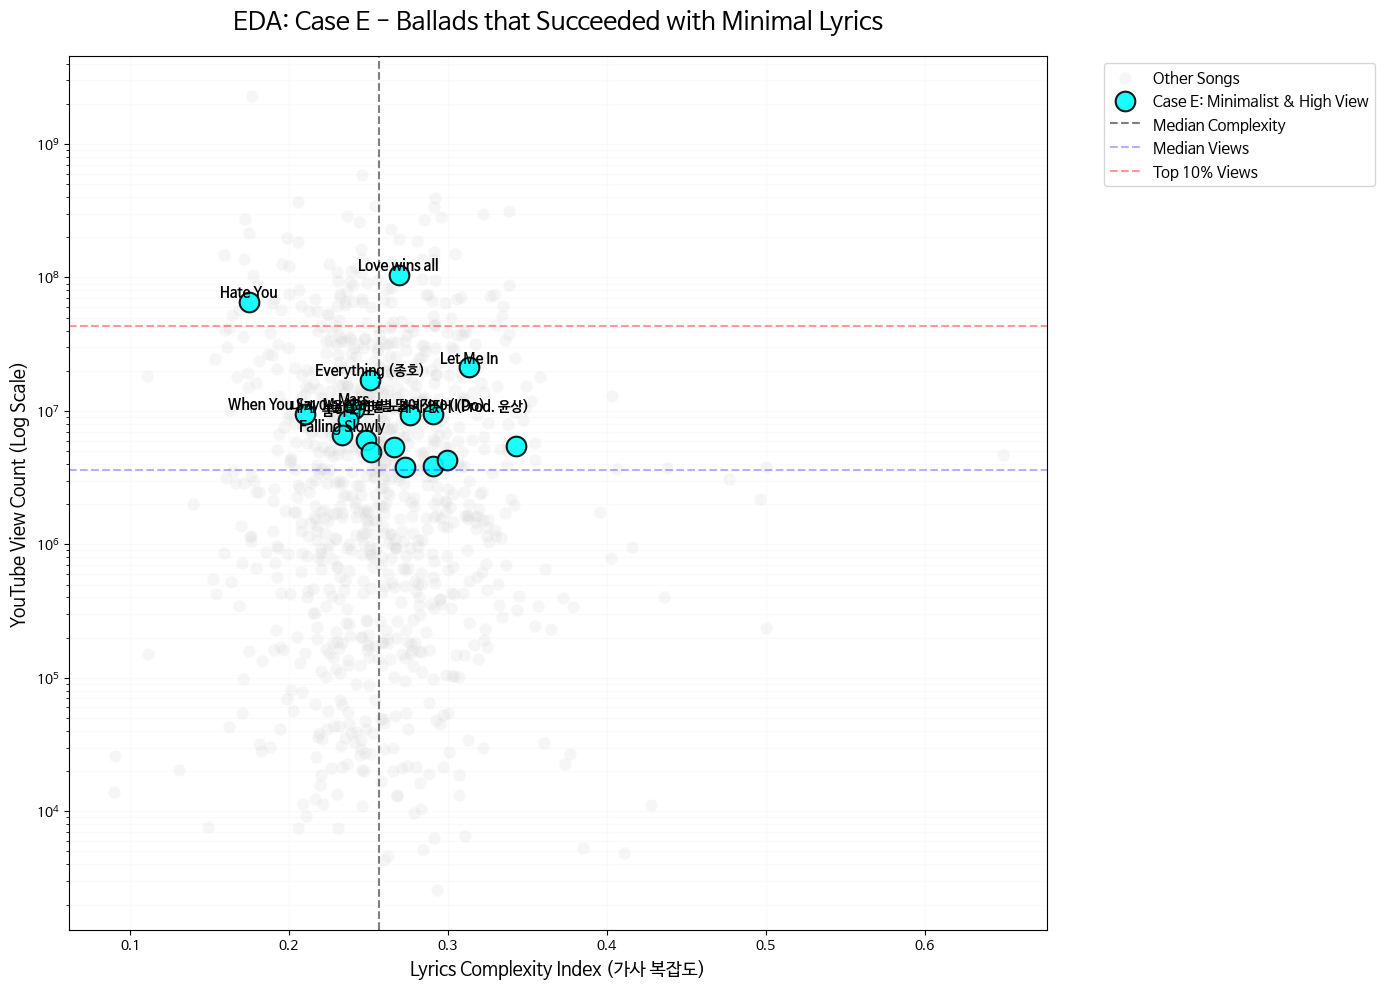

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 그룹 레이블링 (Case E 강조를 위해 단순화)
df_final['group_focus'] = 'Others'
df_final.loc[case_e_final_push.index, 'group_focus'] = 'Case E (Minimalist Ballad)'

# 2. 시각화
plt.figure(figsize=(14, 10))

# 배경: 나머지 곡들 (연하게 처리)
sns.scatterplot(
    data=df_final[df_final['group_focus'] == 'Others'],
    x='lyrics_complexity_index',
    y='api_view_count',
    color='lightgrey',
    alpha=0.2, s=80, label='Other Songs'
)

# 강조: Case E (크고 선명하게 표시)
sns.scatterplot(
    data=df_final[df_final['group_focus'] == 'Case E (Minimalist Ballad)'],
    x='lyrics_complexity_index',
    y='api_view_count',
    color='cyan',
    alpha=0.9, s=200, edgecolor='black', linewidth=1.5,
    label='Case E: Minimalist & High View'
)

# 주요 곡 이름 라벨링 (상위 10곡 정도)
for i, row in case_e_final_push.sort_values('api_view_count', ascending=False).head(10).iterrows():
    plt.text(
        row['lyrics_complexity_index'],
        row['api_view_count'] * 1.1, # 점보다 약간 위에 표시
        row['songName'],
        fontsize=10, fontweight='bold', ha='center'
    )

# 기준선 표시
plt.axvline(df_final['lyrics_complexity_index'].median(), color='black', linestyle='--', alpha=0.5, label='Median Complexity')
plt.axhline(df_final['api_view_count'].median(), color='blue', linestyle='--', alpha=0.3, label='Median Views')
plt.axhline(df_final['api_view_count'].quantile(0.9), color='red', linestyle='--', alpha=0.4, label='Top 10% Views')

plt.yscale('log')
plt.title('EDA: Case E - Ballads that Succeeded with Minimal Lyrics', fontsize=18, pad=20)
plt.xlabel('Lyrics Complexity Index (가사 복잡도)', fontsize=13)
plt.ylabel('YouTube View Count (Log Scale)', fontsize=13)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True, which="both", ls="-", alpha=0.05)
plt.tight_layout()
plt.show()

### 1-21. 전체 Case 종합 비교

**분석**: Case A~E를 모두 한 산점도(복잡도×조회수)에 겹쳐서 전체적인 위치를 비교.

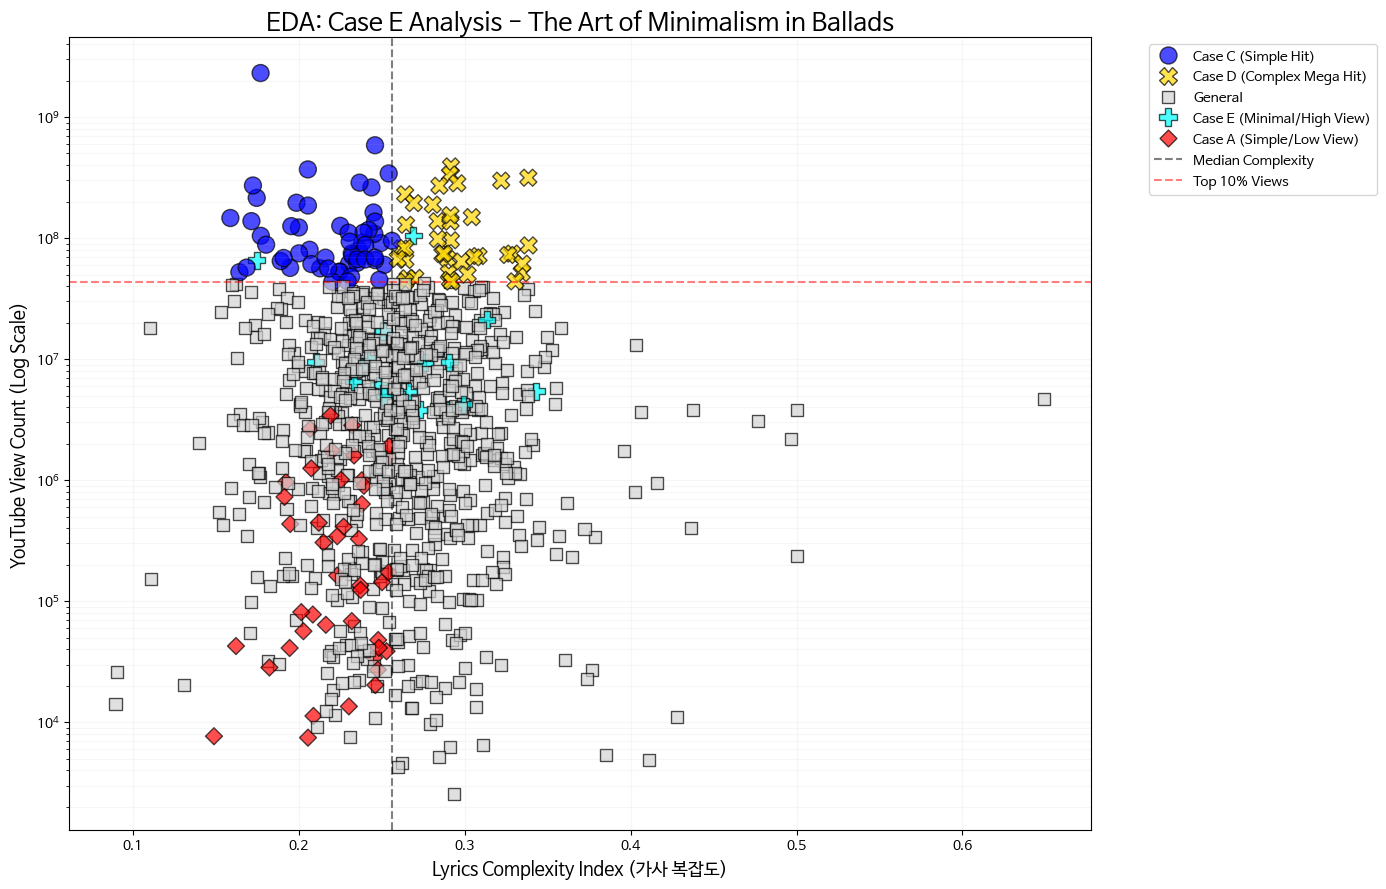

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 모든 케이스 레이블링 통합
df_final['group_final'] = 'General'
df_final.loc[case_a_ballad_low.index, 'group_final'] = 'Case A (Simple/Low View)'
df_final.loc[case_c_simple_hit.index, 'group_final'] = 'Case C (Simple Hit)'
df_final.loc[case_d_complex_mega_hit.index, 'group_final'] = 'Case D (Complex Mega Hit)'
df_final.loc[case_e_final_push.index, 'group_final'] = 'Case E (Minimal/High View)' # Case E 추가

# 2. 시각화
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_final,
    x='lyrics_complexity_index',
    y='api_view_count',
    hue='group_final',
    style='group_final',
    palette={
        'General': 'lightgrey',
        'Case A (Simple/Low View)': 'red',
        'Case C (Simple Hit)': 'blue',
        'Case D (Complex Mega Hit)': 'gold',
        'Case E (Minimal/High View)': 'cyan' # Case E는 시원한 하늘색
    },
    alpha=0.7, s=150, edgecolor='black'
)

# 기준선 표시 (중앙값 및 상위 10%)
plt.axvline(df_final['lyrics_complexity_index'].median(), color='black', linestyle='--', alpha=0.5, label='Median Complexity')
plt.axhline(df_final['api_view_count'].quantile(0.9), color='red', linestyle='--', alpha=0.5, label='Top 10% Views')

plt.yscale('log')
plt.title('EDA: Case E Analysis - The Art of Minimalism in Ballads', fontsize=18)
plt.xlabel('Lyrics Complexity Index (가사 복잡도)', fontsize=13)
plt.ylabel('YouTube View Count (Log Scale)', fontsize=13)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.tight_layout()
plt.show()

### 1-22. 발라드 핵심 근거 ① — 한글 100% 발라드 가사 양 검증

**분석**: 영어 비중 0.01 미만인 순수 한글 발라드만 골라, 조회수 상위 20% vs 하위 20% 그룹의 '줄당 단어수(밀도)'·토큰수를 비교.
**결과**: 성공군 247토큰 vs 실패군 209토큰(약 40단어 차이) → 성공하는 한글 발라드는 이야기를 더 길고 빽빽하게 풀어냄 = 가사 양이 적은 순수 한글 발라드는 흥행하지 못하는 경향.

In [ ]:
# 1. 영어 비중이 거의 없는(0.01 미만) 순수 한글 발라드만 추출
pure_kr_ballad = df_final[
    (df_final['genie_genre'].str.contains('발라드')) &
    (df_final['english_ratio'] < 0.01)
].copy()

# 2. 한 줄당 단어 수(Density) 계산
pure_kr_ballad['words_per_line'] = pure_kr_ballad['token_count'] / pure_kr_ballad['line_count']

# 3. 조회수 상위 20% vs 하위 20% 비교
top_threshold = pure_kr_ballad['api_view_count'].quantile(0.8)
bottom_threshold = pure_kr_ballad['api_view_count'].quantile(0.2)

pure_kr_ballad['perf_group'] = 'Middle'
pure_kr_ballad.loc[pure_kr_ballad['api_view_count'] >= top_threshold, 'perf_group'] = 'Top (Success)'
pure_kr_ballad.loc[pure_kr_ballad['api_view_count'] <= bottom_threshold, 'perf_group'] = 'Bottom (Fail)'

# 결과 출력
density_analysis = pure_kr_ballad.groupby('perf_group')[['token_count', 'line_count', 'words_per_line']].mean()
print("📊 [순수 한글 발라드: 성공 vs 실패 그룹 물리적 구조 비교]")
display(density_analysis)

📊 [순수 한글 발라드: 성공 vs 실패 그룹 물리적 구조 비교]


,token_count,line_count,words_per_line
perf_group,,,
Bottom (Fail),209.909091,33.181818,6.353614
Middle,227.677419,34.774194,6.735399
Top (Success),247.545455,37.000000,6.759534


### 1-23. 발라드 핵심 근거 ② — 가사 오프닝 키워드 3가지 발견

**분석**: 순수 한글 발라드 성공군의 오프닝(첫 소절)에서 자주 쓰인 명사를 추출.
**결과 (의외의 발견 3가지)**: ① 가사 난이도 자체는 성공과 무관, '가수 파워'와 '공감되는 상황(키워드)'이 더 중요 ② 발라드 시장은 '완전 한글파' vs '팝스타일 영어파'로 양극화되어 있고 어중간한 혼용이 불리 ③ 발라드에서 극단적으로 우울한 가사는 메가히트로 이어지기보다 특정 마니아층(충성 팬덤)에 머무는 경향.

In [ ]:
def get_opening_line(lyrics):
    lines = [l.strip() for l in str(lyrics).split('\n') if l.strip()]
    return lines[0] if lines else ""

pure_kr_ballad['opening_line'] = pure_kr_ballad['genie_lyrics'].apply(get_opening_line)

# 성공한 곡들의 오프닝에서 가장 많이 쓰인 명사 추출
top_openings = " ".join(pure_kr_ballad[pure_kr_ballad['perf_group'] == 'Top (Success)']['opening_line'])
opening_nouns = [n for n in okt.nouns(top_openings) if len(n) > 1]

print("🎤 [성공한 한글 발라드의 첫 소절 핵심 키워드 TOP 10]")
display(Counter(opening_nouns).most_common(10))

🎤 [성공한 한글 발라드의 첫 소절 핵심 키워드 TOP 10]


[('세상', 2),
 ('대답', 1),
 ('하루', 1),
 ('아주', 1),
 ('오늘', 1),
 ('파란', 1),
 ('지붕', 1),
 ('아래', 1),
 ('길마', 1),
 ('동쪽', 1)]